# FMO Energy Transfer — Open Quantum Systems Tutorial

This notebook simulates excitonic energy transfer in the **Fenna–Matthews–Olson (FMO)** complex, a well-studied pigment–protein complex found in green sulfur bacteria. The FMO complex has played a landmark role in quantum biology because the quantum coherences observed experimentally in its energy-transfer dynamics sparked intense debate about the role of quantum mechanics in biological function.

We treat the FMO as an **open quantum system**: a three-site excitonic Hamiltonian coupled to a structured bosonic environment, modelled through the HEOM (Hierarchical Equations of Motion) formalism implemented in TENSO.

We will run **six simulations** (3 spectral density models × 2 temperatures) to reproduce the results discussed in the paper:

| Run | Spectral density | Temperature | Output file |
|-----|-----------------|-------------|-------------|
| 1 | Drude–Lorentz | 300 K | `3_level_FMO_dl300_2.dat.log` |
| 2 | Drude–Lorentz | 77 K | `fmo_77K_dl.dat.log` |
| 3 | 3-peak Brownian | 300 K | `3_level_FMO_three_peak_300K.dat.log` |
| 4 | 3-peak Brownian | 77 K | `3_level_FMO_threepeak_77K.dat.log` |
| 5 | Structured 6-peak | 300 K | `3_level_FMO_structured_300K.dat.log` |
| 6 | Structured 6-peak | 77 K | `3_level_FMO_structured_77_2.dat.log` |

In [2]:
from math import ceil
import numpy as np
from tqdm import tqdm

from tenso.prototypes.heom import system_multibath   # multi-bath propagator
from tenso.prototypes.bath import gen_bcf              # BCF generator
from tenso.prototypes.default_parameters import quantity

## The FMO Model: Physical Background

The FMO complex contains seven bacteriochlorophyll (BChl) pigments, but the energy-transfer dynamics within certain pathways can be faithfully captured by a **three-site reduced model** consisting of sites 1, 2, and 3. Each site $n$ corresponds to a two-level chromophore whose excited state $|n\rangle$ contributes to the single-exciton manifold.

### System Hamiltonian

The system Hamiltonian is written in the single-exciton basis $\{|1\rangle, |2\rangle, |3\rangle\}$:

$$
H_S = \begin{pmatrix}
\epsilon_1 & J_{12} & J_{13} \\
J_{12} & \epsilon_2 & J_{23} \\
J_{13} & J_{23} & \epsilon_3
\end{pmatrix},
$$

where $\epsilon_n$ are the site energies and $J_{mn}$ are the electronic couplings (all in cm$^{-1}$).

> **Note:** Insert your Hamiltonian values from your reference image in the code cell below. The values shown are a placeholder from the standard Adolphs–Renger (2006) parametrization for illustrative purposes.

### System–Bath Coupling

Each chromophore is independently coupled to its own local phonon bath. The total Hamiltonian reads

$$
H = H_S + \sum_{n=1}^{3}\left(H_B^{(n)} + H_{SB}^{(n)}\right),
$$

with the system–bath interaction for each site

$$
H_{SB}^{(n)} = Q_n \otimes X_B^{(n)},
$$

where the coupling operator is the **projector onto site $n$**:

$$
Q_n = |n\rangle\langle n|.
$$

This means each site couples diagonally to its own independent bath, so all three environments are statistically independent and characterised by the same spectral density $J(\omega)$ (identical baths assumption).

In [ ]:
# ============================================================
# SYSTEM HAMILTONIAN  (all values in cm^-1)
# ============================================================
# Site energies (diagonal) — INSERT YOUR VALUES from the reference image
epsilon_1 =  200.0   # Site 1 energy (cm^-1)  ← update from your image
epsilon_2 =    0.0   # Site 2 energy (cm^-1)  ← update from your image
epsilon_3 =  320.0   # Site 3 energy (cm^-1)  ← update from your image

# Electronic couplings (off-diagonal) — INSERT YOUR VALUES
J_12 = -87.7         # Coupling between sites 1 and 2 (cm^-1)
J_13 =   5.5         # Coupling between sites 1 and 3 (cm^-1)
J_23 =  30.8         # Coupling between sites 2 and 3 (cm^-1)

H_sys = np.array([
    [epsilon_1, J_12,      J_13     ],
    [J_12,      epsilon_2, J_23     ],
    [J_13,      J_23,      epsilon_3],
], dtype=np.complex128)

print("System Hamiltonian (cm^-1):")
print(H_sys.real)

## Initial State

We initialise the system with the excitation fully localised on **site 1** — the site closest to the chlorosome baseplate, which acts as the antenna input port. The initial reduced density matrix is therefore

$$
\rho_S(0) = |1\rangle\langle 1|.
$$

In [ ]:
# Initial state: excitation on site 1
psi_0 = np.array([1.0, 0.0, 0.0], dtype=np.complex128)   # |site 1>
rdo_0 = np.outer(psi_0, psi_0.conj())

# Propagation parameters
end_time  = 1000.0   # fs
dt        = 1.0      # fs  (adjust for convergence)

print("Initial density matrix:")
print(rdo_0)
print(f"\nPropagation: 0 → {end_time} fs in steps of {dt} fs")

## System–Bath Coupling Operators

The coupling operators $Q_n = |n\rangle\langle n|$ are $3\times 3$ projectors, one per site.

In [ ]:
# Local site projectors: Q_n = |n><n|
Q1 = np.zeros((3, 3), dtype=np.complex128); Q1[0, 0] = 1.0   # |1><1|
Q2 = np.zeros((3, 3), dtype=np.complex128); Q2[1, 1] = 1.0   # |2><2|
Q3 = np.zeros((3, 3), dtype=np.complex128); Q3[2, 2] = 1.0   # |3><3|

sys_ops = [Q1, Q2, Q3]   # one per independent local bath

## Spectral Densities

The spectral density $J(\omega)$ encodes how the phonon bath couples to the chromophore as a function of frequency. We study three models, all consistent with experimental vibrational data for the FMO complex.

### 1. Drude–Lorentz (DL) — Pure Overdamped

The simplest continuum model, describing an overdamped harmonic bath:

$$
J^{\mathrm{DL}}(\omega) = \frac{2}{\pi}\frac{\lambda\,\omega_c\,\omega}{\omega_c^2 + \omega^2},
$$

with reorganization energy $\lambda = 35.0\;\mathrm{cm}^{-1}$ and cutoff $\omega_c = 106.18\;\mathrm{cm}^{-1}$.

### 2. Three-Peak Brownian Oscillators

A structured spectral density built from three underdamped Brownian oscillator modes, capturing the dominant vibrational modes of the BChl–protein scaffold:

$$
J^{\mathrm{3pk}}(\omega) = \sum_{b=1}^{3} \frac{4}{\pi}\frac{\lambda_b\,\Omega_b^2\,\omega\,\gamma_b}{\left[(\omega+\omega_b^{(1)})^2+\gamma_b^2\right]\left[(\omega-\omega_b^{(1)})^2+\gamma_b^2\right]},
$$

where $\omega_b^{(1)} = \sqrt{\Omega_b^2 - \gamma_b^2}$.

### 3. Structured 6-Peak Brownian Oscillators

An extended version of the above with six modes, providing a more accurate representation of the full vibrational sideband structure:

$$
J^{\mathrm{str}}(\omega) = \sum_{b=1}^{6} \frac{4}{\pi}\frac{\lambda_b\,\Omega_b^2\,\omega\,\gamma_b}{\left[(\omega+\omega_b^{(1)})^2+\gamma_b^2\right]\left[(\omega-\omega_b^{(1)})^2+\gamma_b^2\right]}.
$$

All spectral density parameters are listed in the next cell.

In [ ]:
# ============================================================
# SPECTRAL DENSITY PARAMETERS  (all values in cm^-1)
# ============================================================

# --- 1. Drude–Lorentz ---
L_DL   = 35.0       # Reorganization energy λ
Wc_DL  = 106.1767   # Cutoff frequency ωc

# --- 2. Three-peak Brownian Oscillators ---
W_3pk = [160.0, 247.0, 763.0]               # Mode frequencies Ω_b
G_3pk = [133.0,  53.0,  76.0]               # Damping widths γ_b
L_3pk = [ 26.24, 13.832, 101.479]           # Reorganization energies λ_b

# --- 3. Structured 6-peak Brownian Oscillators ---
W_str = [160.0,  247.0,  763.0, 1175.0, 1356.0, 1521.0]
G_str = [133.0,   53.0,   76.0,   29.0,   29.0,   15.0]
L_str = [ 26.24,  13.832, 101.479, 57.575, 25.764,  9.126]

print("Spectral density parameters loaded.")

## Bath Correlation Function (BCF)

The influence of each bath is fully encoded in the **bath correlation function** (BCF):

$$
C(t) = \mathrm{Tr}_B\!\left[\tilde{X}_B(t)\,\tilde{X}_B(0)\,\rho_B^{\mathrm{eq}}\right],
$$

which is related to the spectral density via

$$
C(t) = \int_{-\infty}^{\infty} \mathcal{J}(\omega)\bigl(1 - e^{-\beta\omega}\bigr)^{-1} e^{-i\omega t}\,\mathrm{d}\omega.
$$

For HEOM to be applicable, $C(t)$ must be decomposed into a sum of complex exponentials using either the Matsubara or Padé scheme. Here we use the **(N−1)/N Padé** decomposition:

$$
C(t) = \sum_{k=1}^{K} c_k e^{  \gamma_k t}\quad \mathrm{and} \quad C^*(t) = \sum_{k=1}^{K} \bar{c_k} e^{  \gamma_k t}
$$

where $c_k$ and $\gamma_k$ are complex coefficients determined by `gen_bcf`. The number of low-temperature correction terms `n_ltc` controls the accuracy of the finite-temperature expansion.

> **Same bath model, different temperatures.** For each spectral density we generate two BCF objects — one at 300 K and one at 77 K — and run the propagation separately.

### BCF — Drude–Lorentz

In [ ]:
# Drude–Lorentz BCF at 300 K
bcf_dl_300 = gen_bcf(
    re_d=[L_DL],          # Reorganization energy (cm^-1)
    width_d=[Wc_DL],      # Cutoff frequency (cm^-1)
    temperature=300,      # Temperature (K)
    decomposition_method='Pade',
    n_ltc=3,
)

# Drude–Lorentz BCF at 77 K
bcf_dl_77 = gen_bcf(
    re_d=[L_DL],
    width_d=[Wc_DL],
    temperature=77,
    decomposition_method='Pade',
    n_ltc=3,
)

print("Drude–Lorentz BCFs generated (300 K and 77 K).")

### BCF — Three-Peak Brownian Oscillators

In [ ]:
# 3-peak BCF at 300 K
bcf_3pk_300 = gen_bcf(
    freq_b=W_3pk,         # Mode frequencies (cm^-1)
    re_b=L_3pk,           # Reorganization energies (cm^-1)
    width_b=G_3pk,        # Damping widths (cm^-1)
    temperature=300,
    decomposition_method='Pade',
    n_ltc=3,
)

# 3-peak BCF at 77 K
bcf_3pk_77 = gen_bcf(
    freq_b=W_3pk,
    re_b=L_3pk,
    width_b=G_3pk,
    temperature=77,
    decomposition_method='Pade',
    n_ltc=3,
)

print("3-peak BCFs generated (300 K and 77 K).")

### BCF — Structured 6-Peak Brownian Oscillators

In [ ]:
# Structured 6-peak BCF at 300 K
bcf_str_300 = gen_bcf(
    freq_b=W_str,
    re_b=L_str,
    width_b=G_str,
    temperature=300,
    decomposition_method='Pade',
    n_ltc=3,
)

# Structured 6-peak BCF at 77 K
bcf_str_77 = gen_bcf(
    freq_b=W_str,
    re_b=L_str,
    width_b=G_str,
    temperature=77,
    decomposition_method='Pade',
    n_ltc=3,
)

print("6-peak structured BCFs generated (300 K and 77 K).")

## HEOM Propagation

We propagate the reduced density matrix $\rho_S(t)$ using the HEOM framework. For the multi-bath case (one independent local bath per site), we use `system_multi_bath`, which accepts:

- `sys_ops` — list of coupling operators, one per bath (here $[Q_1, Q_2, Q_3]$).
- `bath_correlations` — list of BCF objects, one per bath (all identical since we assume the same spectral density at every site).
- `dim` — the HEOM hierarchy truncation depth. A good starting value is **3–5** for structured spectral densities; increase if populations have not converged.

Each run writes a `.dat.log` file whose columns correspond to the complex elements of $\rho_S(t)$ ordered **row by row**:

$$
\text{cols: } t,\; \rho_{11},\; \rho_{12},\; \rho_{13},\; \rho_{21},\; \rho_{22},\; \rho_{23},\; \rho_{31},\; \rho_{32},\; \rho_{33}.
$$

The file-name passed to `fname` (without extension) must match the table at the top of this notebook **exactly** so that the plotting script can locate each file.

In [ ]:
def run_fmo(fname, bath_correlations, dim=4):
    """
    Propagate the 3-site FMO model and save populations to fname.dat.log.

    Parameters
    ----------
    fname : str
        Output file name prefix (no extension).
    bath_correlations : list
        One BCF object per site [bcf_site1, bcf_site2, bcf_site3].
    dim : int
        HEOM hierarchy depth.
    """
    propagator = system_multibath(
        fname=fname,
        init_rdo=rdo_0,
        sys_ham=H_sys,
        sys_ops=sys_ops,                   # [Q1, Q2, Q3]
        bath_correlations=bath_correlations,
        dim=dim,
        end_time=end_time,
        step_time=dt,
        save_checkpoint_to_file=True,
    )

    progress_bar = tqdm(propagator, total=ceil(end_time / dt))
    for _t in progress_bar:
        progress_bar.set_description(f'@{_t:.1f} fs  [{fname}]')

    print(f"Done → {fname}.dat.log")

## Run 1 & 2 — Drude–Lorentz Spectral Density

In [ ]:
# Run 1: DL at 300 K  →  3_level_FMO_dl300_2.dat.log
run_fmo(
    fname='3_level_FMO_dl300_2',
    bath_correlations=[bcf_dl_300, bcf_dl_300, bcf_dl_300],
    dim=5,
)

In [ ]:
# Run 2: DL at 77 K  →  fmo_77K_dl.dat.log
run_fmo(
    fname='fmo_77K_dl',
    bath_correlations=[bcf_dl_77, bcf_dl_77, bcf_dl_77],
    dim=5,
)

## Run 3 & 4 — Three-Peak Brownian Spectral Density

In [ ]:
# Run 3: 3-peak at 300 K  →  3_level_FMO_three_peak_300K.dat.log
run_fmo(
    fname='3_level_FMO_three_peak_300K',
    bath_correlations=[bcf_3pk_300, bcf_3pk_300, bcf_3pk_300],
    dim=4,
)

In [ ]:
# Run 4: 3-peak at 77 K  →  3_level_FMO_threepeak_77K.dat.log
run_fmo(
    fname='3_level_FMO_threepeak_77K',
    bath_correlations=[bcf_3pk_77, bcf_3pk_77, bcf_3pk_77],
    dim=4,
)

## Run 5 & 6 — Structured 6-Peak Brownian Spectral Density

In [ ]:
# Run 5: 6-peak structured at 300 K  →  3_level_FMO_structured_300K.dat.log
run_fmo(
    fname='3_level_FMO_structured_300K',
    bath_correlations=[bcf_str_300, bcf_str_300, bcf_str_300],
    dim=4,
)

In [ ]:
# Run 6: 6-peak structured at 77 K  →  3_level_FMO_structured_77_2.dat.log
run_fmo(
    fname='3_level_FMO_structured_77_2',
    bath_correlations=[bcf_str_77, bcf_str_77, bcf_str_77],
    dim=4,
)

## Quick Sanity Check

After all six runs complete, the cell below verifies that all output files exist and plots the diagonal populations for a fast visual check. This uses the same loading convention as the plotting notebook.

C:\Users\night\AppData\Local\Temp\ipykernel_30908\1264326784.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.965))


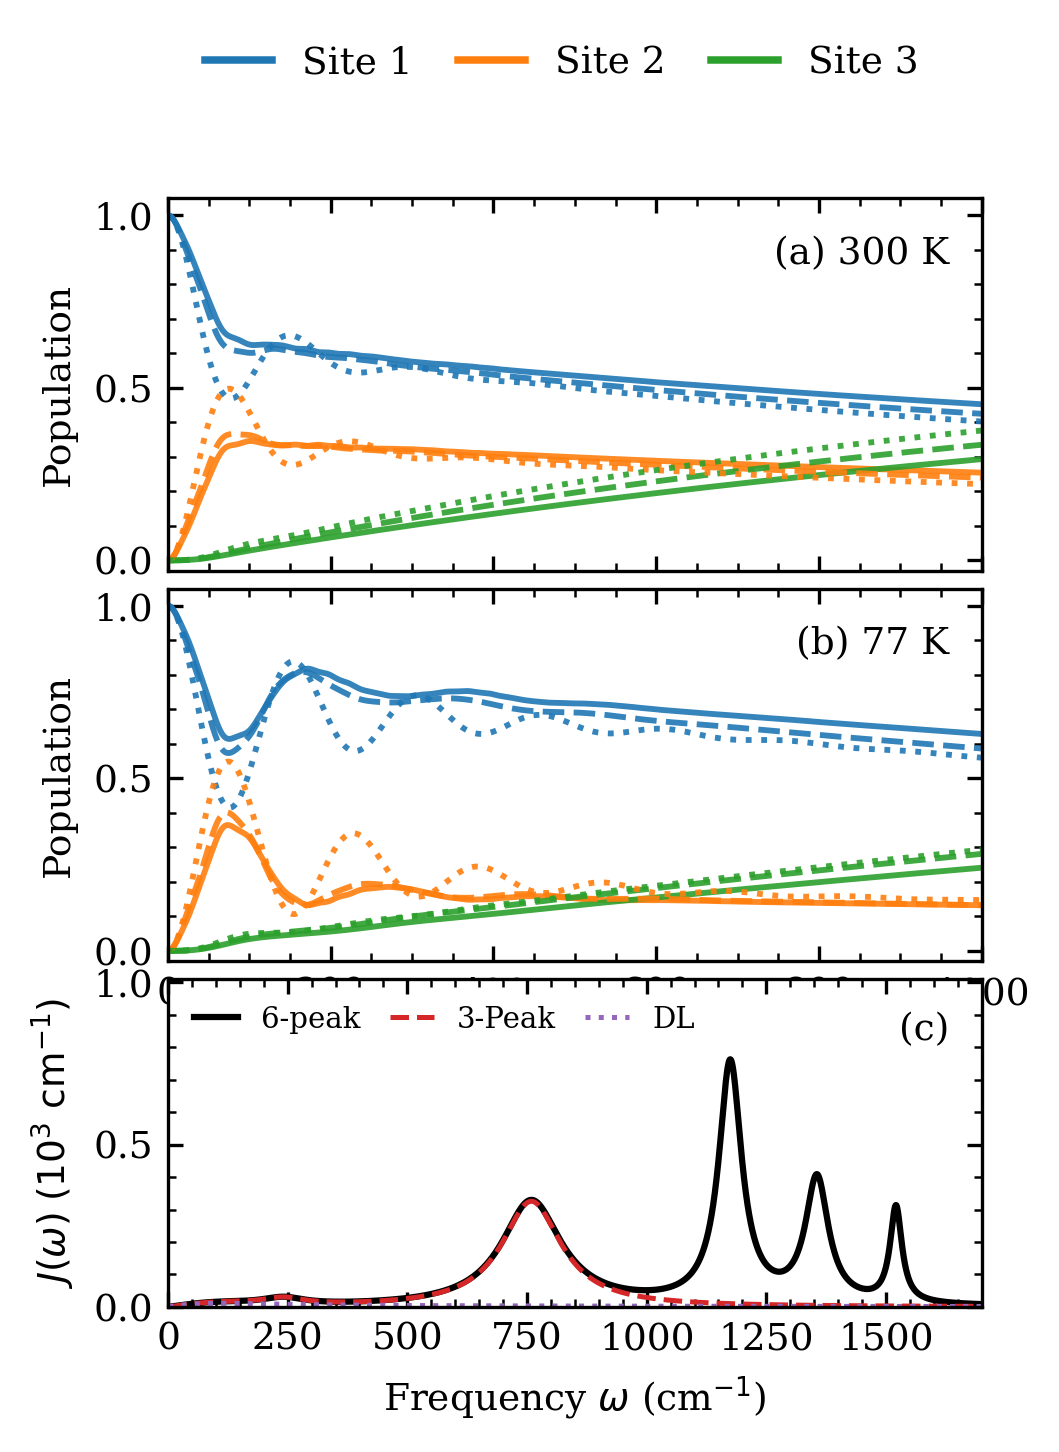

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

# ── File Paths ────────────────────────────────────────────────────────────────

files = {
    "str": {
        "300K": Path("3_level_FMO_structured_300K.dat.log"),
        "77K":  Path("3_level_FMO_structured_77_2.dat.log"),
    },
    "3pk": {
        "300K": Path("3_level_FMO_three_peak_300K.dat.log"),
        "77K":  Path("3_level_FMO_threepeak_77K.dat.log"),
    },
    "DL": {
        "300K": Path("3_level_FMO_dl300_2.dat.log"),
        "77K":  Path("fmo_77K_dl.dat.log"),
    },
}

# ── Spectral Density Parameters (cm^-1) ──────────────────────────────────────

W_str = np.array([160, 247, 763, 1175, 1356, 1521], dtype=float)
G_str = np.array([133,  53,  76,   29,   29,   15], dtype=float)
L_str = np.array([26.24, 13.832, 101.479, 57.575, 25.764, 9.126])

W_3pk = np.array([160, 247, 763], dtype=float)
G_3pk = np.array([133,  53,  76], dtype=float)
L_3pk = np.array([26.24, 13.832, 101.479])

L_DL, Wc_DL = 35.0, 106.1767


# ── Functions ─────────────────────────────────────────────────────────────────

def load_populations(fname):
    raw = np.genfromtxt(fname, comments="#", dtype=complex)
    t  = raw[:, 0].real
    p1 = raw[:, 1].real   # ρ₁₁
    p2 = raw[:, 5].real   # ρ₂₂
    p3 = raw[:, 9].real   # ρ₃₃
    return t, np.vstack([p1, p2, p3]).T

def j_brownian(w, W, G, L):
    J = np.zeros_like(w, dtype=float)
    for w0, g, lam in zip(W, G, L):
        w1 = np.sqrt(max(w0**2 - g**2, 0.0))
        J += (4.0/np.pi) * lam * g * w0**2 * w / (
            ((w + w1)**2 + g**2) * ((w - w1)**2 + g**2)
        )
    return J

def j_drude(w, lam, wc):
    return (2.0/np.pi) * (lam * wc * w) / (w**2 + wc**2)


# ── Style ─────────────────────────────────────────────────────────────────────

plt.rcParams.update({
    "font.family":         "serif",
    "font.size":           9,
    "axes.labelsize":      9,
    "axes.linewidth":      0.8,
    "lines.linewidth":     1.4,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.top":           True,
    "ytick.right":         True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi":          300,
})

site_colors = {0: "tab:blue", 1: "tab:orange", 2: "tab:green"}
model_ls    = {"str": "-", "3pk": "--", "DL": ":"}

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1, figsize=(3.5, 4.8), sharex=False,
    gridspec_kw={"height_ratios": [1, 1, 0.88], "hspace": 0.05}
)


# ── Panels (a) and (b): Populations ──────────────────────────────────────────

for ax, temp, label in [(ax1, "300K", "(a) 300 K"), (ax2, "77K", "(b) 77 K")]:
    for model in ["str", "3pk", "DL"]:
        t, pops = load_populations(files[model][temp])
        for si in range(3):
            ax.plot(t, pops[:, si],
                    color=site_colors[si],
                    linestyle=model_ls[model],
                    alpha=0.9)
    ax.set_ylabel("Population")
    ax.text(0.96, 0.90, label, transform=ax.transAxes,
            ha='right', va='top', fontsize=9)
    ax.set_xlim(0, 1000)
    ax.set_ylim(-0.03, 1.05)
    ax.set_yticks([0.0, 0.5, 1.0])

ax1.tick_params(labelbottom=False)
ax2.set_xlabel(r"Time (fs)")


# ── Panel (c): Spectral Densities ────────────────────────────────────────────

w_cm  = np.linspace(1, 1700, 2000)
J_str = j_brownian(w_cm, W_str, G_str, L_str)
J_3pk = j_brownian(w_cm, W_3pk, G_3pk, L_3pk)
J_dru = j_drude(w_cm, L_DL, Wc_DL)

ax3.plot(w_cm, J_str/1000, color="k",          linestyle="-",  lw=1.5, label="6-peak")
ax3.plot(w_cm, J_3pk/1000, color="tab:red",    linestyle="--", lw=1.2, label="3-Peak")
ax3.plot(w_cm, J_dru/1000, color="tab:purple", linestyle=":",  lw=1.2, label="DL")

ax3.set_ylabel(r"$J(\omega)\;(10^3\ \mathrm{cm}^{-1})$")
ax3.set_xlabel(r"Frequency $\omega$ (cm$^{-1}$)")
ax3.text(0.96, 0.90, "(c)", transform=ax3.transAxes,
         ha='right', va='top', fontsize=9)
ax3.set_xlim(0, 1700)
ax3.set_ylim(0, 1.01)
ax3.legend(fontsize=7, frameon=False, loc="upper left", ncol=3,
           handlelength=1.5, columnspacing=1.0)


# ── Top legend: site colors ───────────────────────────────────────────────────

fig.legend(
    handles=[
        Line2D([0], [0], color="tab:blue",   linewidth=1.8, label="Site 1"),
        Line2D([0], [0], color="tab:orange", linewidth=1.8, label="Site 2"),
        Line2D([0], [0], color="tab:green",  linewidth=1.8, label="Site 3"),
    ],
    loc="upper center", bbox_to_anchor=(0.5, 1.01),
    ncol=3, fontsize=9, frameon=False,
    handlelength=1.8, columnspacing=1.2,
)

fig.tight_layout(rect=(0, 0, 1, 0.965))
plt.savefig("FMO_populations.png", bbox_inches='tight', dpi=300, facecolor='white')
plt.show()